# BANK LOAN ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #creating 2d graphs
import seaborn as sns #creating more statistical analysis
import warnings #if warnings will be there then it will give more structured warnings like explaination of it
import plotly.express as px #mostly used for interactive line,area & scatter charts

In [2]:
df = pd.read_excel('financial_loan.xlsx')

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [5]:
df.shape

(38576, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [7]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [8]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## Key performance Indicator

In [9]:
#Total loan Applications

Total_loan_application = df['id'].count()
print("Total loan Application:", Total_loan_application)

Total loan Application: 38576


In [10]:
# MTD loan applications

latest_issue_date = df['issue_date'].max()  #to get the latest date by max func
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_application = mtd_data['id'].count()

print(f"MTD Loan Application (for {latest_issue_date.strftime('%B %Y')}) : {mtd_loan_application}")

MTD Loan Application (for December 2021) : 4314


In [11]:
# Total funded amount

total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print(f"Total Funded Amount : ${total_funded_amount_millions:.2f}M")

Total Funded Amount : $435.76M


In [12]:
# MTS funded amount

latest_issue_date = df['issue_date'].max()  #to get the latest date by max func
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()

mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000

print(f"MTD Funded Amount (for {latest_issue_date.strftime('%B %Y')}) : ${mtd_total_funded_amount_millions:.2f}M")

MTD Funded Amount (for December 2021) : $53.98M


In [13]:
#Total Amount Received

total_amount_received = df['total_payment'].sum()
total_amount_received_millions = total_amount_received/1000000
print(f"Total Amount Received: ${total_amount_received_millions:.2f}M")

Total Amount Received: $473.07M


In [14]:
# MTS amount received

latest_issue_date = df['issue_date'].max()  #to get the latest date by max func
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_amount_received = mtd_data['total_payment'].sum()

mtd_total_amount_received_millions = mtd_total_amount_received/1000000

print(f"MTD Amount Received (for {latest_issue_date.strftime('%B %Y')}) : ${mtd_total_amount_received_millions:.2f}M")

MTD Amount Received (for December 2021) : $58.07M


In [15]:
# Average Interest rate

average_interest_rate = df['int_rate'].mean()*100
print(f"Average Int Rate: {average_interest_rate:.2f}%")

Average Int Rate: 12.05%


In [16]:
# Average Debt-to-Income Ratio (DTI)

average_Debt_to_income_Ratio = df['dti'].mean()*100
print(f"Average_Debt_to_Income_Ratio: {average_Debt_to_income_Ratio:.2f}%")

Average_Debt_to_Income_Ratio: 13.33%


## Good Loan Metrics

In [17]:
good_loan = df[df['loan_status'].isin(['Fully Paid','Current'])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loan['id'].count()
good_loan_funded_amount = good_loan['loan_amount'].sum()
good_loan_amount_received = good_loan['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount/1000000
good_loan_amount_received_millions = good_loan_amount_received/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications) * 100

print(f"Good Loan Applications: {good_loan_applications}")
print(f"Good Loan Funded Amount: ${good_loan_funded_amount_millions:.2f}M")
print(f"Good Loan Amount received: ${good_loan_amount_received_millions:.2f}M")
print(f"Good Loan Percentage: {good_loan_percentage:.2f}%")


Good Loan Applications: 33243
Good Loan Funded Amount: $370.22M
Good Loan Amount received: $435.79M
Good Loan Percentage: 86.18%


## Bad Loan Metrics

In [18]:
bad_loan = df[df['loan_status'].isin(['Charged Off'])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum()
bad_loan_amount_received = bad_loan['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount/1000000
bad_loan_amount_received_millions = bad_loan_amount_received/1000000

bad_loan_percentage = (bad_loan_applications/total_loan_applications) * 100

print(f"Bad Loan Applications: {bad_loan_applications}")
print(f"Bad Loan Funded Amount: ${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad Loan Amount received: ${bad_loan_amount_received_millions:.2f}M")
print(f"Bad Loan Percentage: {bad_loan_percentage:.2f}%")

Bad Loan Applications: 5333
Bad Loan Funded Amount: $65.53M
Bad Loan Amount received: $37.28M
Bad Loan Percentage: 13.82%


## Visualisations

### monthly trends by issue date for total funded amount

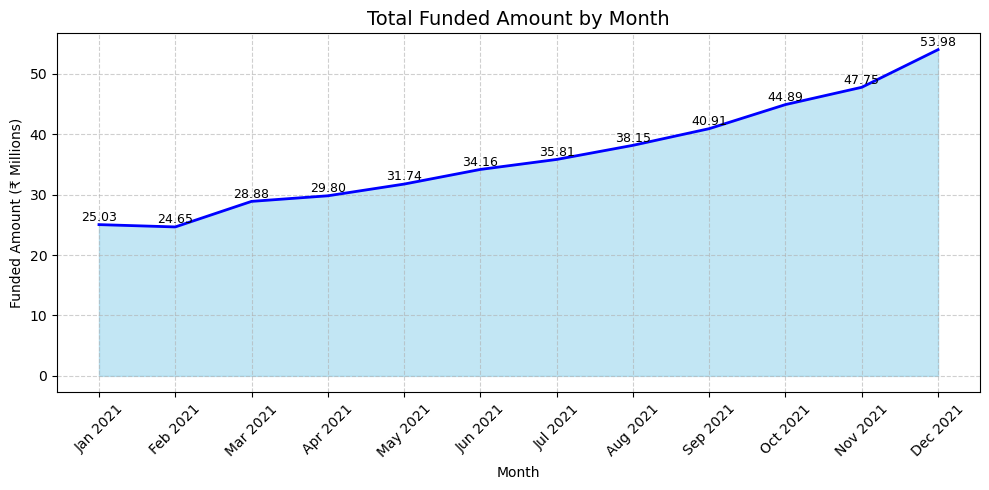

In [19]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name',sort=False)['loan_amount']
      .sum()
      .div(1_000_000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='blue',linewidth=2)

for i,row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions'] + 0.1, f"{row['loan_amount_millions']:.2f}",
             ha = 'center', va='bottom',fontsize=9, rotation=0, color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (₹ Millions)')
plt.xticks(ticks=range(len(monthly_funded)), labels=monthly_funded['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### monthly trends by issue date for total amount received

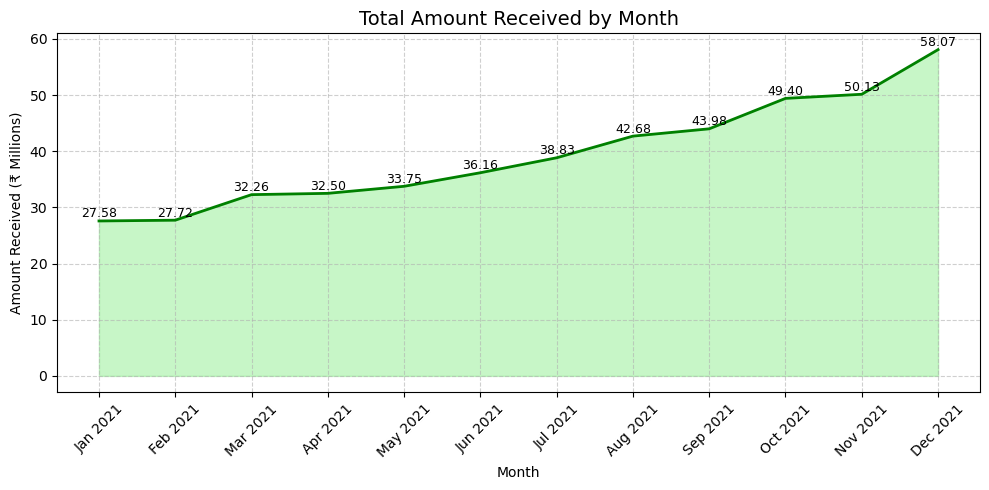

In [20]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name',sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_received['month_name'],monthly_received['received_amount_millions'],color='lightgreen',alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['received_amount_millions'],color='green',linewidth=2)

for i,row in monthly_received.iterrows():
    plt.text(i,row['received_amount_millions'] + 0.1, f"{row['received_amount_millions']:.2f}",
             ha = 'center', va='bottom',fontsize=9, rotation=0, color='black')

plt.title('Total Amount Received by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Amount Received (₹ Millions)')
plt.xticks(ticks=range(len(monthly_received)), labels=monthly_received['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### monthly trends by issue date for total loan applications

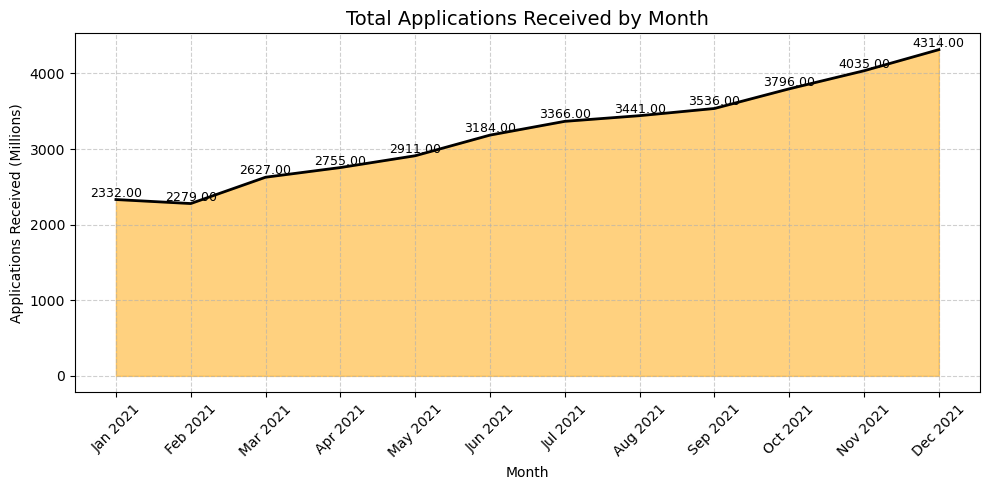

In [21]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name',sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['loan_applications_count'],color='orange',alpha=0.5)
plt.plot(monthly_applications['month_name'],monthly_applications['loan_applications_count'],color='black',linewidth=2)

for i,row in monthly_applications.iterrows():
    plt.text(i,row['loan_applications_count'] + 0.1, f"{row['loan_applications_count']:.2f}",
             ha = 'center', va='bottom',fontsize=9, rotation=0, color='black')

plt.title('Total Applications Received by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Applications Received (Millions)')
plt.xticks(ticks=range(len(monthly_applications)), labels=monthly_applications['month_name'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

In [22]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


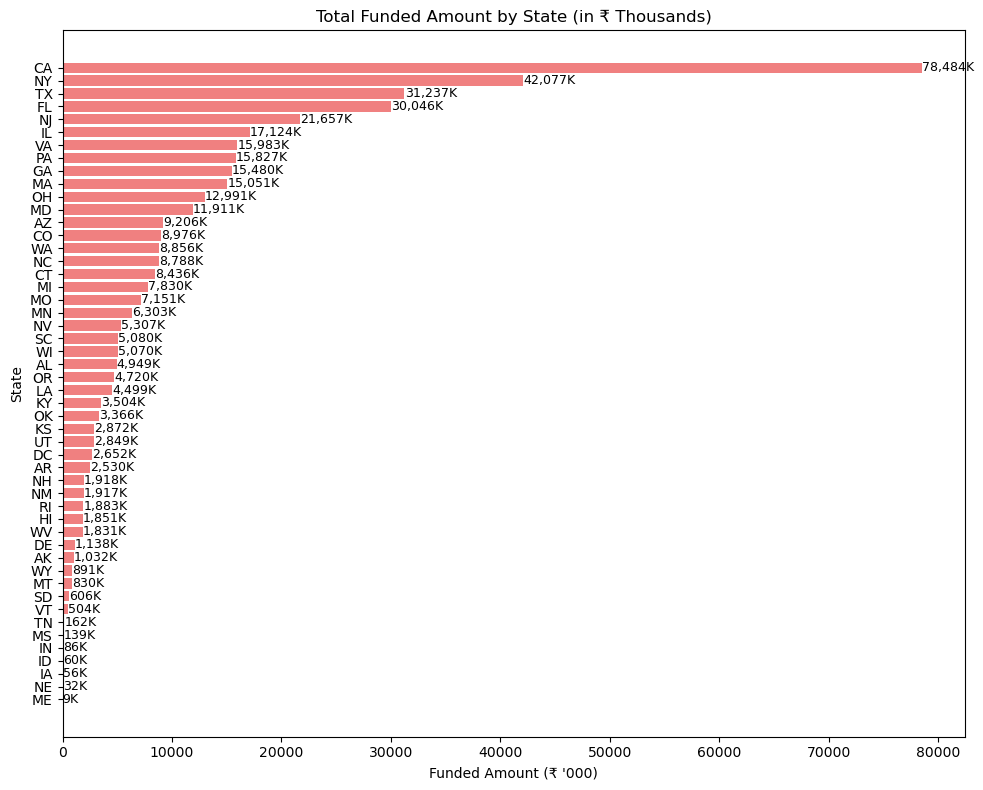

In [26]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Funded Amount by State (in ₹ Thousands)')
plt.xlabel('Funded Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Received Amount

In [28]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


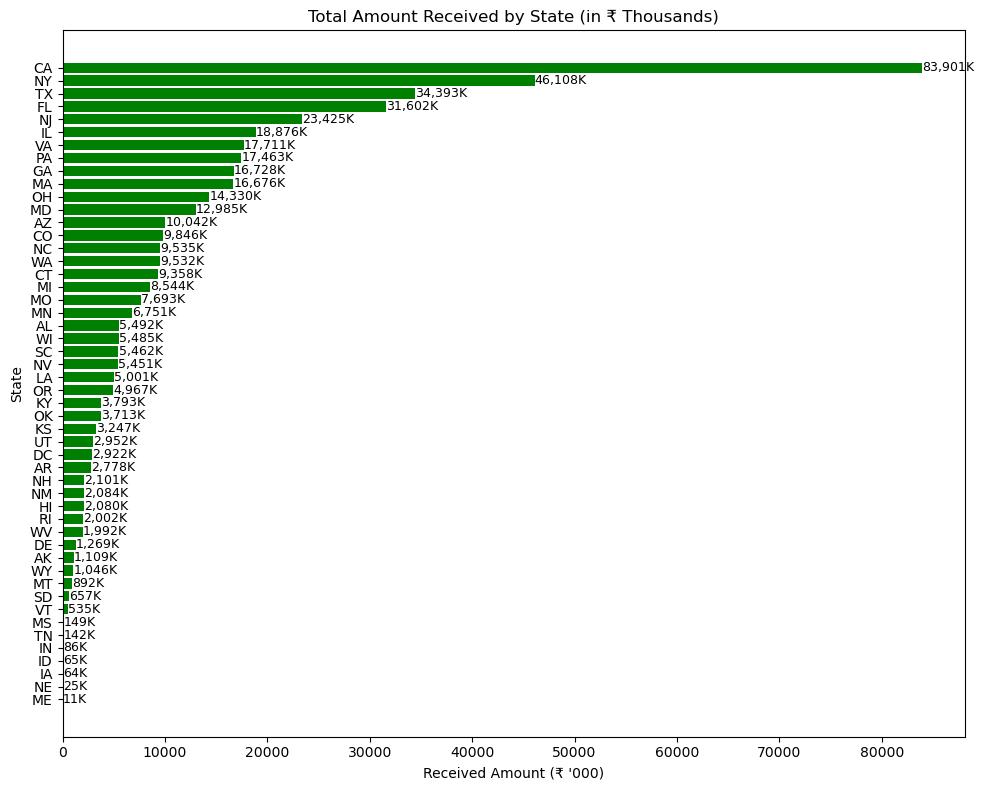

In [29]:
state_funding = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10,8))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color='green')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K', va='center', fontsize=9)

plt.title('Total Amount Received by State (in ₹ Thousands)')
plt.xlabel('Received Amount (₹ \'000)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Applications Received

In [30]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


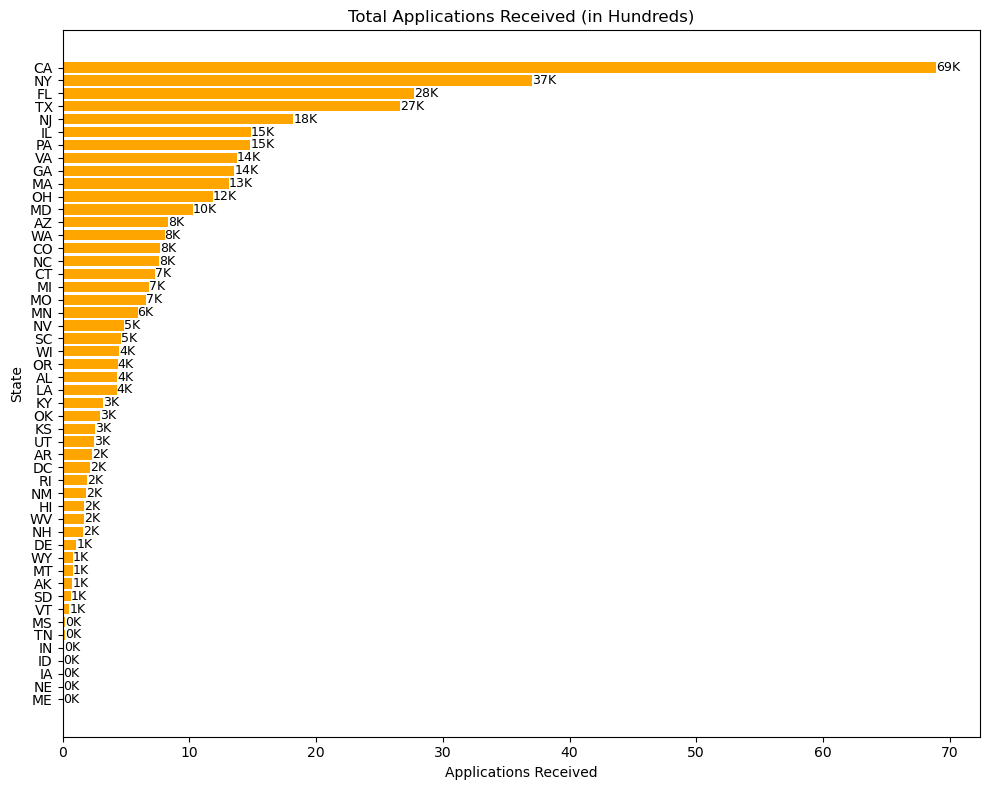

In [37]:
state_applications = df.groupby('address_state')['id'].count().sort_values(ascending=True)
state_applications_hundreds = state_applications / 100

plt.figure(figsize=(10,8))
bars = plt.barh(state_applications_hundreds.index, state_applications_hundreds.values, color='orange')

max_val = state_applications_hundreds.max()  # ← get max value
offset = max_val * 0.01

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}K',va='center',fontsize=9)

plt.title('Total Applications Received (in Hundreds)')
plt.xlabel('Applications Received')
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Long Term Analysis by Total Funded Amount

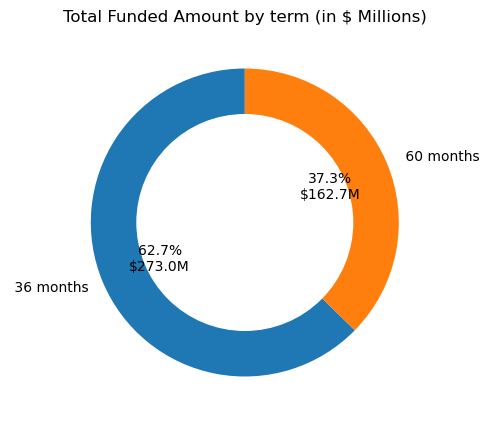

In [39]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0,0), 0.70, color='white'))
plt.title('Total Funded Amount by term (in $ Millions)')
plt.show()

### Long Term Analysis by Total Amount Received

In [40]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


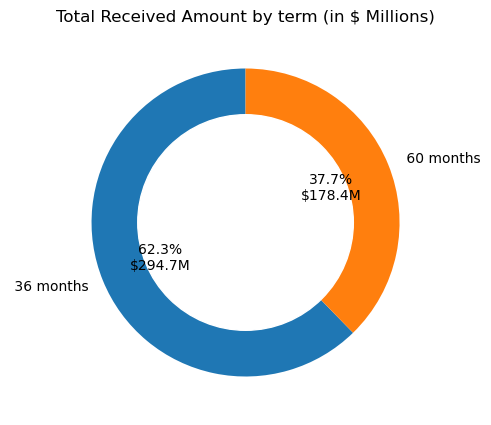

In [42]:
term_received_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize=(5,5))
plt.pie(
    term_received_millions,
    labels = term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*sum(term_received_millions)/100:.1f}M",
    startangle = 90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0,0), 0.70, color='white'))
plt.title('Total Received Amount by term (in $ Millions)')
plt.show()

### Long Term Analysis by Total Applications Received

In [43]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


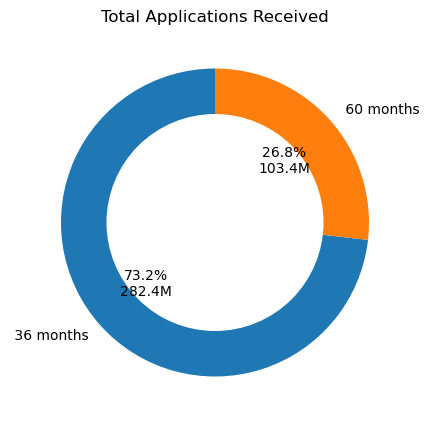

In [46]:
term_applications_received = df.groupby('term')['id'].count()/100

plt.figure(figsize=(5,5))
plt.pie(
    term_applications_received,
    labels = term_applications_received.index,
    autopct=lambda p: f"{p:.1f}%\n{p*sum(term_applications_received)/100:.1f}M",
    startangle = 90,
    wedgeprops={'width': 0.4}
)
plt.gca().add_artist(plt.Circle((0,0), 0.70, color='white'))
plt.title('Total Applications Received')
plt.show()

### Employee Length Analysis by Total Funded Amount

In [48]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


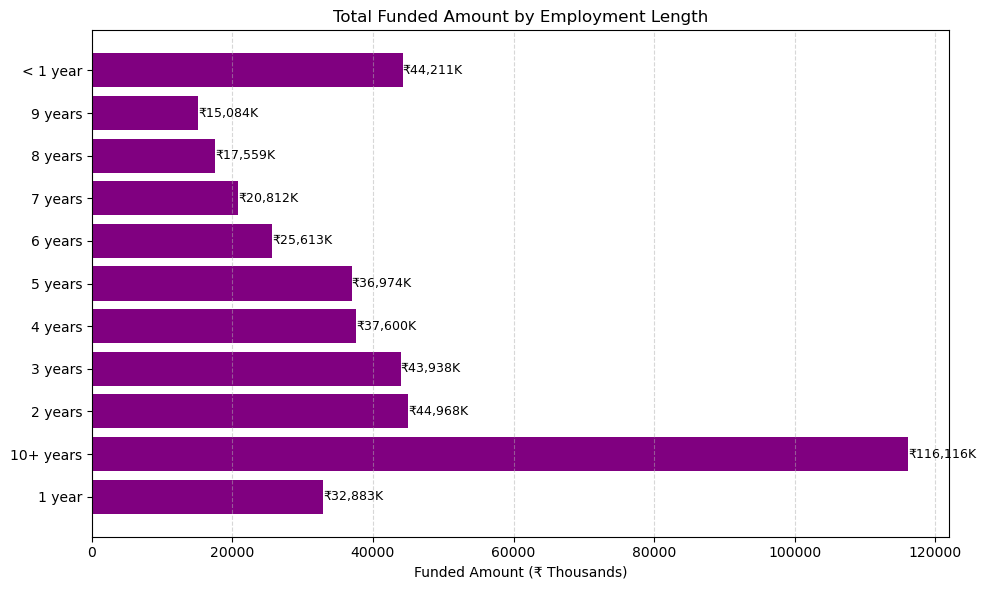

In [50]:
emp_funding_thousands = df.groupby('emp_length')['loan_amount'].sum() / 1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index, emp_funding_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"₹{width:,.0f}K", va='center', fontsize=9)

plt.xlabel("Funded Amount (₹ Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Employee Length Analysis by Total Amount Received

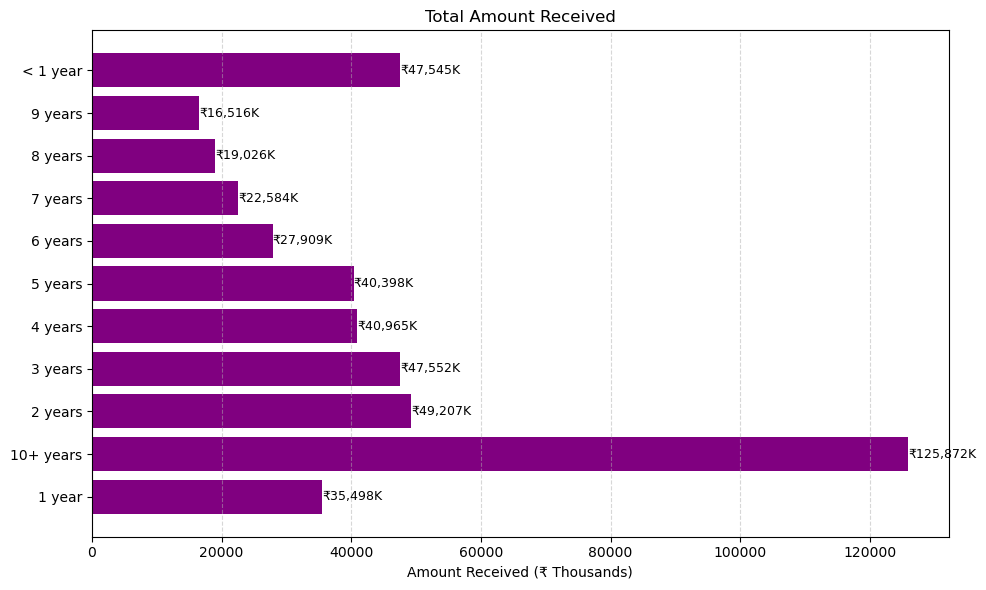

In [51]:
emp_amount_received_thousands = df.groupby('emp_length')['total_payment'].sum() / 1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_amount_received_thousands.index, emp_amount_received_thousands, color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height() / 2,
             f"₹{width:,.0f}K", va='center', fontsize=9)

plt.xlabel("Amount Received (₹ Thousands)")
plt.title("Total Amount Received")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Funded Amount

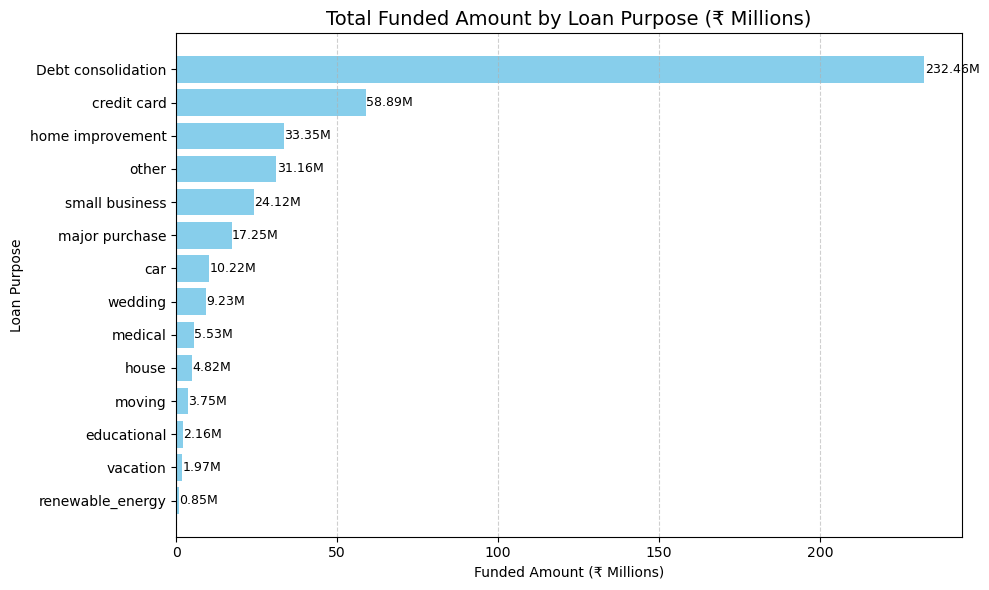

In [52]:
purpose_funding_millions = (df.groupby('purpose')['loan_amount'].sum().sort_values()/ 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_funding_millions.index, purpose_funding_millions.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}M', va='center', fontsize=9)

plt.title('Total Funded Amount by Loan Purpose (₹ Millions)', fontsize=14)
plt.xlabel('Funded Amount (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Amount Received

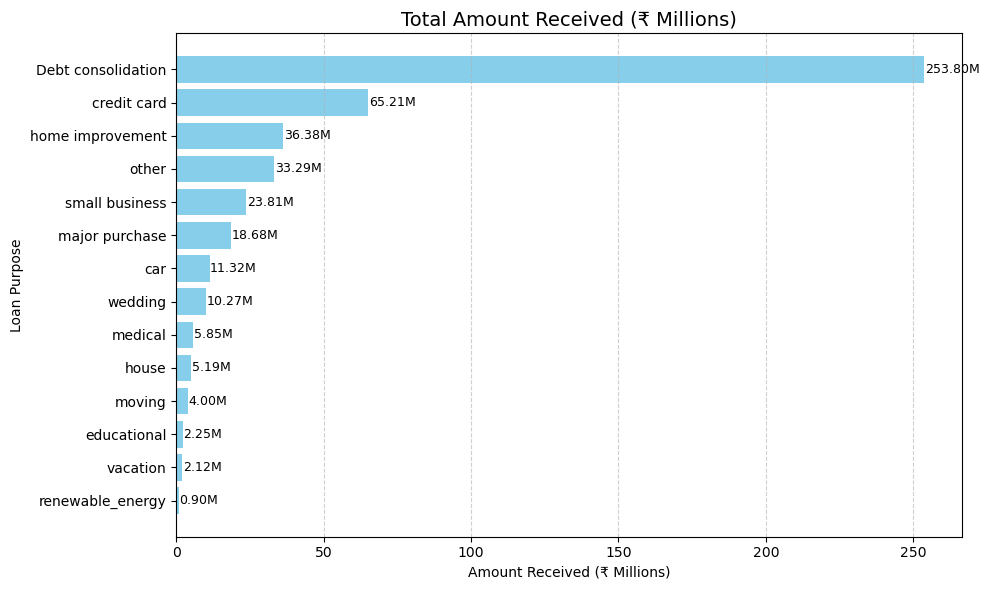

In [54]:
purpose_amount_received_millions = (df.groupby('purpose')['total_payment'].sum().sort_values()/ 1000000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_amount_received_millions.index, purpose_amount_received_millions.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}M', va='center', fontsize=9)

plt.title('Total Amount Received (₹ Millions)', fontsize=14)
plt.xlabel('Amount Received (₹ Millions)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Loan Purpose by Total Applications Received

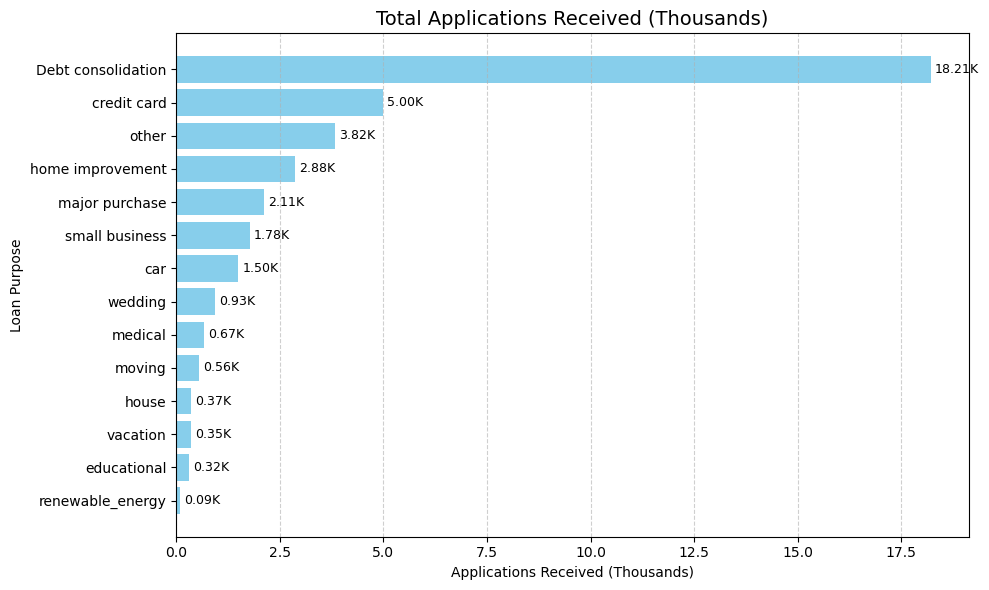

In [57]:
purpose_applications_received_thousands = (df.groupby('purpose')['id'].count().sort_values()/ 1000)

plt.figure(figsize=(10, 6))
bars = plt.barh(purpose_applications_received_thousands.index, purpose_applications_received_thousands.values, color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{width:.2f}K', va='center', fontsize=9)

plt.title('Total Applications Received (Thousands)', fontsize=14)
plt.xlabel('Applications Received (Thousands)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Home Ownership by Total Funded Amount

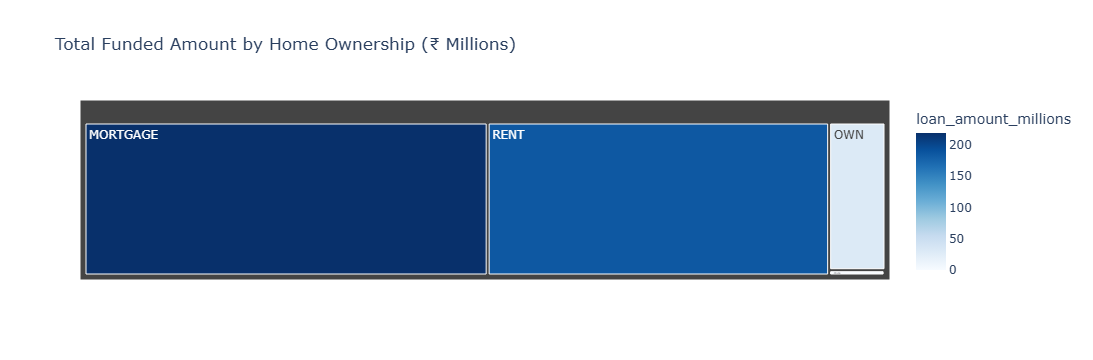

In [59]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1000000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership by Total Amount Received

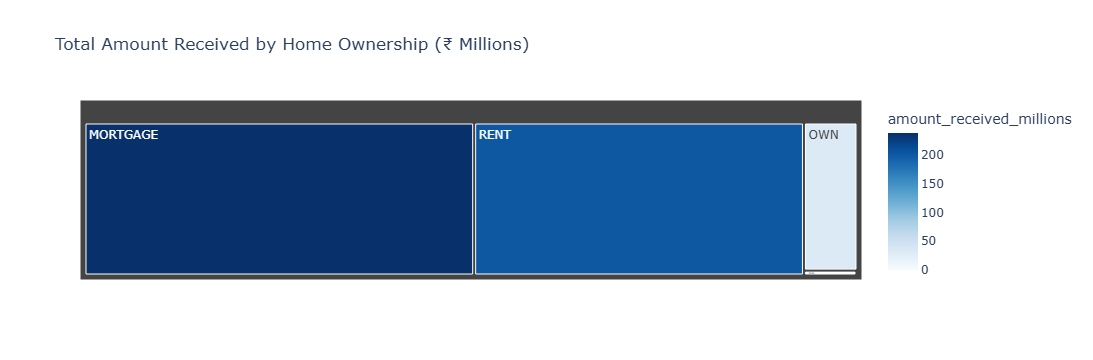

In [65]:
home_amount_received = df.groupby('home_ownership')['total_payment'].sum().reset_index()
home_amount_received['amount_received_millions'] = home_amount_received['total_payment'] / 1000000

fig = px.treemap(
    home_amount_received,
    path=['home_ownership'],
    values='amount_received_millions',
    color='amount_received_millions',
    color_continuous_scale='Blues',
    title='Total Amount Received by Home Ownership (₹ Millions)'
)

fig.show()

### Home Ownership by Total Applications Received

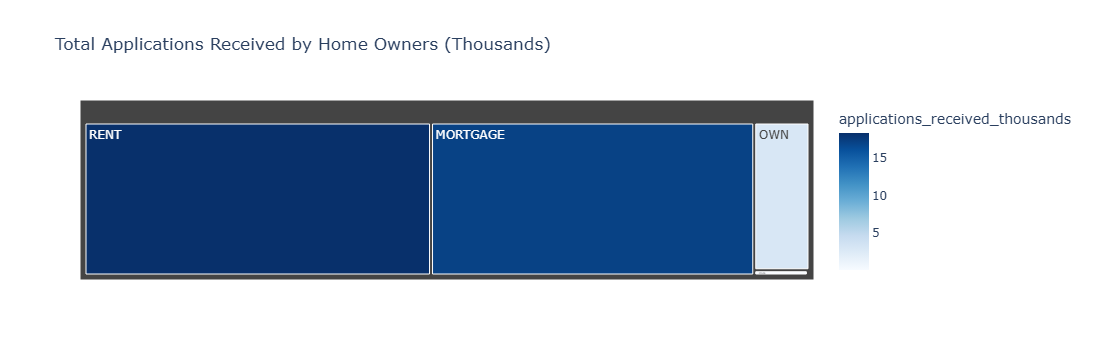

In [67]:
home_applications_received = df.groupby('home_ownership')['id'].count().reset_index()
home_applications_received['applications_received_thousands'] = home_applications_received['id'] / 1000

fig = px.treemap(
    home_applications_received,
    path=['home_ownership'],
    values='applications_received_thousands',
    color='applications_received_thousands',
    color_continuous_scale='Blues',
    title='Total Applications Received by Home Owners (Thousands)'
)

fig.show()

## Thank You